In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, accuracy_score, confusion_matrix, classification_report, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.linear_model import LogisticRegression


In [76]:
df = pd.read_csv(r"D:\Sem_4\Supervised Machine Learning lab (SMLL)\8\Practice dataset Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [77]:
# Display basic information about the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"The dataset has {df.isnull().sum().sum()} missing values.")
print(f"The dataset has {df.duplicated().sum()} duplicated rows.")
print(f"The dataset has info\n", df.info())
print(f"The dataset has columns\n", df.columns)
print(f"The dataset has description \n", df.describe())


The dataset has 400 rows and 5 columns.
The dataset has 0 missing values.
The dataset has 0 duplicated rows.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
The dataset has info
 None
The dataset has columns
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')
The dataset has description 
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.55

In [78]:
# Data Preprocessing
df.drop(["User ID"], axis=1, inplace=True)
# Encoding categorical data
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])

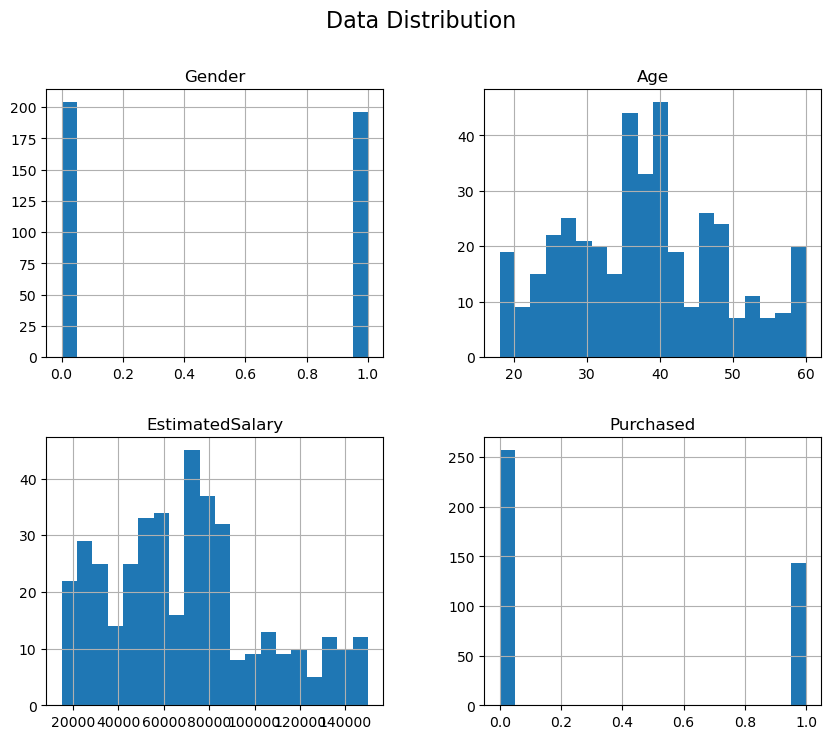

In [79]:
# Data Distribution
plt.Figure(figsize=(10, 5))
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Data Distribution", fontsize=16)
plt.show()

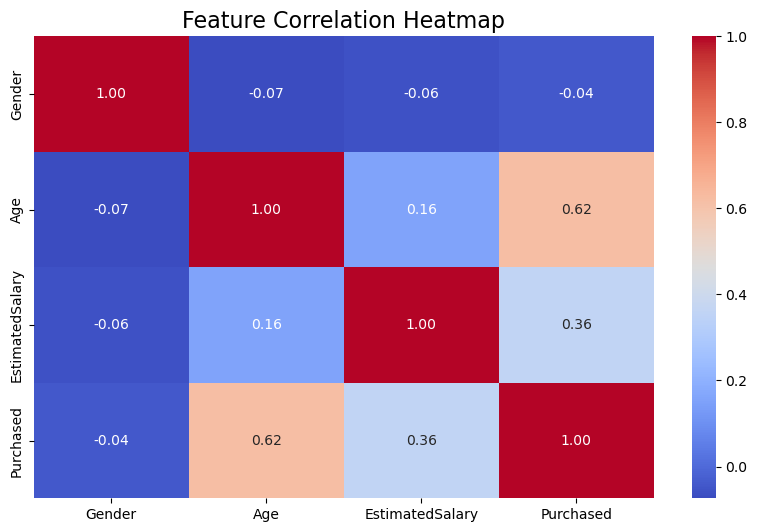

In [80]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [81]:
# Splitting Data into Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]
print(X.shape, y.shape)

(400, 3) (400,)


In [82]:
# Applying SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original dataset shape: {X.shape, y.shape}")
print(f"Resampled dataset shape: {X_resampled.shape, y_resampled.shape}")

Original dataset shape: ((400, 3), (400,))
Resampled dataset shape: ((514, 3), (514,))


In [83]:
# Update df with resampled data
df_resampled = X_resampled.copy()
df_resampled['Outcome'] = y_resampled
df_resampled.head()

,Gender,Age,EstimatedSalary,Outcome
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


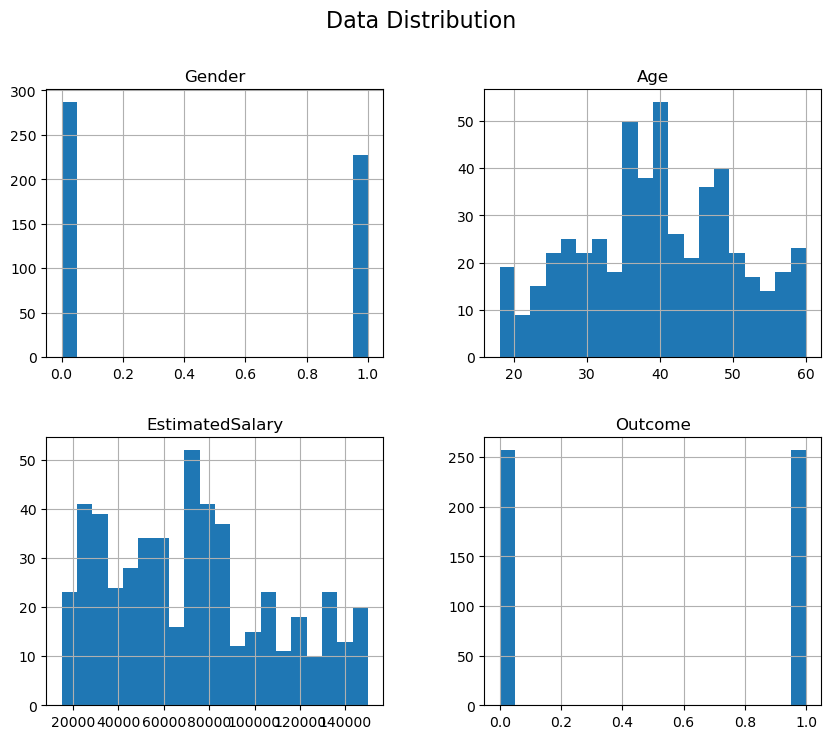

In [84]:
# Data Distribution
plt.Figure(figsize=(10, 5))
df_resampled.hist(figsize=(10, 8), bins=20)
plt.suptitle("Data Distribution", fontsize=16)
plt.show()

In [85]:
# Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [86]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [87]:
# Model Training - Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [88]:
# Model Prediction
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [89]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC Score:", roc_auc)
print("classification_report:\n", classification_report(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7864077669902912
F1 Score: 0.8
Precision: 0.7457627118644068
Recall: 0.8627450980392157
ROC AUC Score: 0.8917797888386123
classification_report:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77        52
           1       0.75      0.86      0.80        51

    accuracy                           0.79       103
   macro avg       0.79      0.79      0.79       103
weighted avg       0.79      0.79      0.79       103

confusion_matrix:
 [[37 15]
 [ 7 44]]


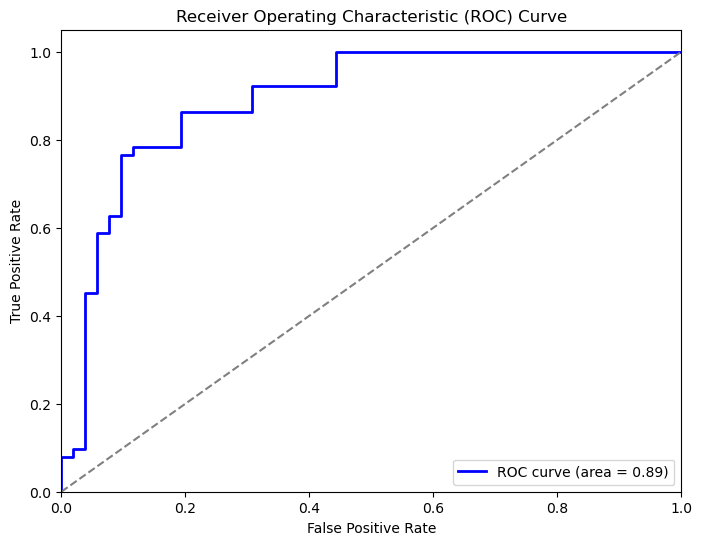

In [90]:
# ROC - AUC curve
fpr,tpr,_ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()